# Libraries

In [170]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({
                    "text.usetex": True,
                    "font.family": "serif",
                    "font.serif": ["Times New Roman"],
                    "axes.unicode_minus": False,
                })
# from sklearn.metrics import mean_squared_error, r2_score
# pd.set_option('display.max_columns', None)
# import numpy as np

# Read dataset

In [171]:
df = pd.read_excel('data_models.xlsx', sheet_name='dataset')
df.columns = df.columns.str.lower().str.replace(' ', '-')
df.head()

,autor,diâmetro-da-armadura-f-(mm),número-de-barras-em-uma-camada,espaçamento-entre-as-barras-(mm),resistência-à-tração-do-concreto-fctm-(mpa),cobrimento-c-(mm),distância-ao-centro-de-gravidade-da-armadura-d'-(mm),taxa-de-armadura-r,tensão-na-armadura-(mpa),tension-stiffening-(b),tensão-na-armadura-na-fissuração-do-concreto-(ssr),ss---bssr-(mpa),wexp-(mm)
0,Viga S200-1.76-20 - Sokolov et al (2021),20.0,2,126.0,4.120341,25.0,39.0,0.060724,231.811005,0.515850,90.135975,185.314362,0.16
1,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,304.251944,0.372710,90.135975,270.657365,0.23
2,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,314.282228,0.334820,90.135975,284.102901,0.24
3,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,363.319171,0.176945,90.135975,347.370061,0.27
4,NaN,20.0,2,126.0,4.120341,25.0,39.0,0.060724,459.164106,0.052750,90.135975,454.409433,0.35


# Statistics

### Summary

In [172]:
df_x = df.describe().T
df_x.drop(columns=["count"], inplace=True)
df_x

,mean,std,min,25%,50%,75%,max
diâmetro-da-armadura-f-(mm),17.910643,6.272794,9.520000,12.000000,16.000000,20.000000,35.800000
número-de-barras-em-uma-camada,2.497076,1.365148,1.000000,2.000000,2.000000,3.750000,9.000000
espaçamento-entre-as-barras-(mm),63.710341,46.755024,12.000000,40.000000,46.000000,69.800000,296.000000
resistência-à-tração-do-concreto-fctm-(mpa),3.096916,0.514515,2.384602,2.800000,2.920876,3.269000,5.308474
cobrimento-c-(mm),32.647807,10.871746,12.800000,25.000000,30.000000,40.000000,70.000000
distância-ao-centro-de-gravidade-da-armadura-d'-(mm),43.761988,12.119438,23.900000,35.000000,40.950000,49.100000,94.500000
taxa-de-armadura-r,0.050929,0.042848,0.007960,0.017479,0.044148,0.065231,0.221883
tensão-na-armadura-(mpa),309.432666,91.257643,106.512655,244.795079,297.459578,367.776857,628.000000
tension-stiffening-(b),0.360226,0.171707,0.000000,0.242154,0.387113,0.485401,0.600000
tensão-na-armadura-na-fissuração-do-concreto-(ssr),138.207936,96.501844,40.180305,65.347574,90.135975,207.320634,372.604414


### Latex export

In [173]:
latex_table = df_x.to_latex(
                            index=True, 
                            float_format="%.3f",
                            caption="Dataset statistics summary.",
                            label="tab:stats_summary",
                            longtable=False,
                            escape=False  
                        )
print(latex_table)

\begin{table}
\caption{Dataset statistics summary.}
\label{tab:stats_summary}
\begin{tabular}{lrrrrrrr}
\toprule
 & mean & std & min & 25% & 50% & 75% & max \\
\midrule
diâmetro-da-armadura-f-(mm) & 17.911 & 6.273 & 9.520 & 12.000 & 16.000 & 20.000 & 35.800 \\
número-de-barras-em-uma-camada & 2.497 & 1.365 & 1.000 & 2.000 & 2.000 & 3.750 & 9.000 \\
espaçamento-entre-as-barras-(mm) & 63.710 & 46.755 & 12.000 & 40.000 & 46.000 & 69.800 & 296.000 \\
resistência-à-tração-do-concreto-fctm-(mpa) & 3.097 & 0.515 & 2.385 & 2.800 & 2.921 & 3.269 & 5.308 \\
cobrimento-c-(mm) & 32.648 & 10.872 & 12.800 & 25.000 & 30.000 & 40.000 & 70.000 \\
distância-ao-centro-de-gravidade-da-armadura-d'-(mm) & 43.762 & 12.119 & 23.900 & 35.000 & 40.950 & 49.100 & 94.500 \\
taxa-de-armadura-r & 0.051 & 0.043 & 0.008 & 0.017 & 0.044 & 0.065 & 0.222 \\
tensão-na-armadura-(mpa) & 309.433 & 91.258 & 106.513 & 244.795 & 297.460 & 367.777 & 628.000 \\
tension-stiffening-(b) & 0.360 & 0.172 & 0.000 & 0.242 & 0.387 & 0.4

### Models

In [174]:
df = pd.read_excel('data_models.xlsx', sheet_name='models')
df.columns = df.columns.str.lower().str.replace(' ', '-')
df.head()

,wexp-(mm),fib-model-code-2010,fib-model-code-2020,eurocode-2,nbr-6118---wk1---fissuração-estabilizada,nbr-6118---wk2---fissuração-não-estabilizada,clark-(1956),leonhardt-(1977),desayi-ganesan-(1985),oh-kang-(1987),caldas-(1997),gergely-e-lutz-(1968),-b--variável-e_menor_zero_seis,equação-(15)-do-artigo-de-belarbi-e-hsu-(1994),beta-conforme-fields-e-bischoff-(2004),slip-de-yuan-et-al-(2025),slip-de-biscaia-e-soares-(2020)
0,0.16,0.125734,0.086159,0.125292,0.262468,0.157380,0.181006,0.296374,0.312684,0.185969,0.129998,0.241528,0.102130,0.149956,0.116566,0.109686,0.082007
1,0.23,0.176982,0.147127,0.176359,0.344489,0.271111,0.244363,0.447049,0.410398,0.256204,0.174746,0.317005,0.190783,0.204348,0.197288,0.193326,0.156266
2,0.24,0.184078,0.155568,0.183430,0.355846,0.289281,0.253135,0.467000,0.423928,0.265928,0.180941,0.327456,0.203058,0.212052,0.208041,0.205301,0.167096
3,0.27,0.218769,0.196838,0.217999,0.411368,0.386596,0.296022,0.562498,0.490072,0.313472,0.211232,0.378549,0.263069,0.250139,0.259368,0.265222,0.221958
4,0.35,0.286574,0.277502,0.285566,0.519888,0.617471,0.379848,0.742678,0.619355,0.406398,0.270437,0.478411,0.380363,0.311870,0.354810,0.388948,0.338382


In [175]:
cols = df.columns.tolist()
cols.pop(0)
cols_models = cols.copy()
cols_models

['fib-model-code-2010',
 'fib-model-code-2020',
 'eurocode-2',
 'nbr-6118---wk1---fissuração-estabilizada',
 'nbr-6118---wk2---fissuração-não-estabilizada',
 'clark-(1956)',
 'leonhardt-(1977)',
 'desayi-ganesan-(1985)',
 'oh-kang-(1987)',
 'caldas-(1997)',
 'gergely-e-lutz-(1968)',
 '-b--variável-e_menor_zero_seis',
 'equação-(15)-do-artigo-de-belarbi-e-hsu-(1994)',
 'beta-conforme-fields-e-bischoff-(2004)',
 'slip-de-yuan-et-al-(2025)',
 'slip-de-biscaia-e-soares-(2020)']

### Numerical models statistics: $w_{model}/ w_{exp}$

In [176]:
for coluna in cols_models:
    df[f'{coluna}-div-wexp-(mm)'] = df[coluna] / df['wexp-(mm)']
df.head()

,wexp-(mm),fib-model-code-2010,fib-model-code-2020,eurocode-2,nbr-6118---wk1---fissuração-estabilizada,nbr-6118---wk2---fissuração-não-estabilizada,clark-(1956),leonhardt-(1977),desayi-ganesan-(1985),oh-kang-(1987),...,leonhardt-(1977)-div-wexp-(mm),desayi-ganesan-(1985)-div-wexp-(mm),oh-kang-(1987)-div-wexp-(mm),caldas-(1997)-div-wexp-(mm),gergely-e-lutz-(1968)-div-wexp-(mm),-b--variável-e_menor_zero_seis-div-wexp-(mm),equação-(15)-do-artigo-de-belarbi-e-hsu-(1994)-div-wexp-(mm),beta-conforme-fields-e-bischoff-(2004)-div-wexp-(mm),slip-de-yuan-et-al-(2025)-div-wexp-(mm),slip-de-biscaia-e-soares-(2020)-div-wexp-(mm)
0,0.16,0.125734,0.086159,0.125292,0.262468,0.157380,0.181006,0.296374,0.312684,0.185969,...,1.852338,1.954276,1.162307,0.812485,1.509550,0.638311,0.937226,0.728538,0.685535,0.512541
1,0.23,0.176982,0.147127,0.176359,0.344489,0.271111,0.244363,0.447049,0.410398,0.256204,...,1.943692,1.784339,1.113929,0.759763,1.378284,0.829489,0.888470,0.857774,0.840549,0.679418
2,0.24,0.184078,0.155568,0.183430,0.355846,0.289281,0.253135,0.467000,0.423928,0.265928,...,1.945832,1.766365,1.108035,0.753923,1.364401,0.846073,0.883550,0.866837,0.855420,0.696232
3,0.27,0.218769,0.196838,0.217999,0.411368,0.386596,0.296022,0.562498,0.490072,0.313472,...,2.083324,1.815083,1.161007,0.782342,1.402032,0.974328,0.926442,0.960621,0.982303,0.822067
4,0.35,0.286574,0.277502,0.285566,0.519888,0.617471,0.379848,0.742678,0.619355,0.406398,...,2.121938,1.769586,1.161136,0.772678,1.366889,1.086752,0.891058,1.013742,1.111280,0.966805


### Summary

In [182]:
cols_models.append('wexp-(mm)')
df_models = df.drop(columns=cols_models)
desc = df_models.describe()
skew = df_models.skew()
kurt = df_models.kurtosis()
desc.loc['skewness'] = skew
desc.loc['kurtosis'] = kurt
df_x = desc.T
df_x.drop(columns=["count"], inplace=True)
df_x

,mean,std,min,25%,50%,75%,max,skewness,kurtosis
fib-model-code-2010-div-wexp-(mm),0.860696,0.275184,0.035845,0.669205,0.831805,1.063259,1.561775,0.090073,0.062116
fib-model-code-2020-div-wexp-(mm),0.852736,0.254702,0.192985,0.674356,0.848713,0.995123,1.574500,0.300891,0.114783
eurocode-2-div-wexp-(mm),0.911113,0.312953,0.241073,0.721076,0.869290,1.076883,2.020206,0.817655,1.267853
nbr-6118---wk1---fissuração-estabilizada-div-wexp-(mm),1.113372,0.337889,0.239873,0.880870,1.151932,1.355376,2.013550,-0.127581,-0.417286
nbr-6118---wk2---fissuração-não-estabilizada-div-wexp-(mm),1.251528,0.622211,0.199315,0.840363,1.127546,1.595437,4.535839,1.475947,4.162280
clark-(1956)-div-wexp-(mm),0.937151,0.442938,0.163406,0.604949,0.840504,1.172418,2.187616,0.875054,0.281905
leonhardt-(1977)-div-wexp-(mm),1.356519,0.430546,0.168176,1.082772,1.366804,1.610829,2.411021,-0.168623,-0.104935
desayi-ganesan-(1985)-div-wexp-(mm),1.160131,0.449000,0.397831,0.786717,1.129986,1.478184,2.356312,0.404887,-0.677811
oh-kang-(1987)-div-wexp-(mm),0.879878,0.296665,0.245849,0.654653,0.882726,1.107976,1.550299,-0.108264,-0.736356
caldas-(1997)-div-wexp-(mm),0.811437,0.216363,0.322475,0.675054,0.793100,0.921778,1.683561,0.727461,1.499061


### Latex export

In [183]:
latex_table = df_x.to_latex(
                            index=True, 
                            float_format="%.3f",
                            caption="Model statistics summary.",
                            label="tab:model_stats_summary",
                            longtable=False,
                            escape=False  
                        )
print(latex_table)

\begin{table}
\caption{Model statistics summary.}
\label{tab:model_stats_summary}
\begin{tabular}{lrrrrrrrrr}
\toprule
 & mean & std & min & 25% & 50% & 75% & max & skewness & kurtosis \\
\midrule
fib-model-code-2010-div-wexp-(mm) & 0.861 & 0.275 & 0.036 & 0.669 & 0.832 & 1.063 & 1.562 & 0.090 & 0.062 \\
fib-model-code-2020-div-wexp-(mm) & 0.853 & 0.255 & 0.193 & 0.674 & 0.849 & 0.995 & 1.575 & 0.301 & 0.115 \\
eurocode-2-div-wexp-(mm) & 0.911 & 0.313 & 0.241 & 0.721 & 0.869 & 1.077 & 2.020 & 0.818 & 1.268 \\
nbr-6118---wk1---fissuração-estabilizada-div-wexp-(mm) & 1.113 & 0.338 & 0.240 & 0.881 & 1.152 & 1.355 & 2.014 & -0.128 & -0.417 \\
nbr-6118---wk2---fissuração-não-estabilizada-div-wexp-(mm) & 1.252 & 0.622 & 0.199 & 0.840 & 1.128 & 1.595 & 4.536 & 1.476 & 4.162 \\
clark-(1956)-div-wexp-(mm) & 0.937 & 0.443 & 0.163 & 0.605 & 0.841 & 1.172 & 2.188 & 0.875 & 0.282 \\
leonhardt-(1977)-div-wexp-(mm) & 1.357 & 0.431 & 0.168 & 1.083 & 1.367 & 1.611 & 2.411 & -0.169 & -0.105 \\
desayi-ga

### Charts

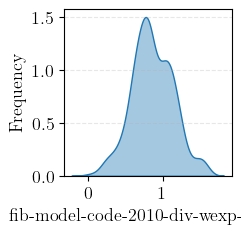

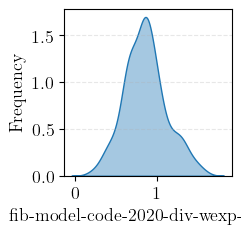

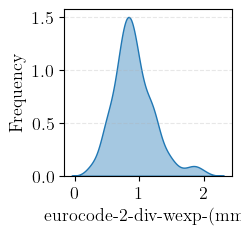

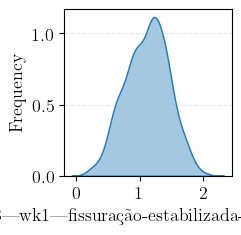

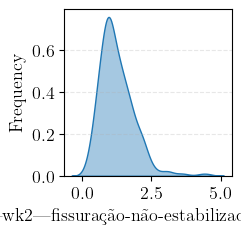

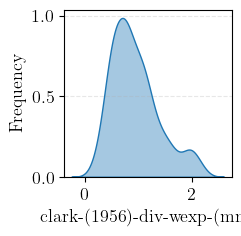

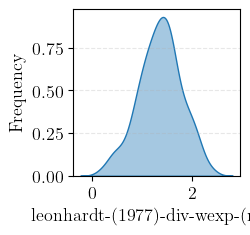

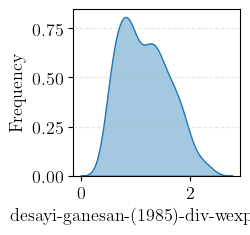

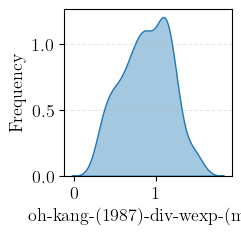

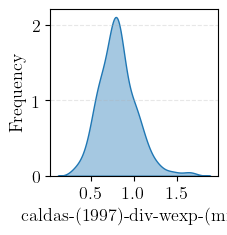

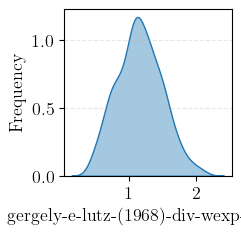

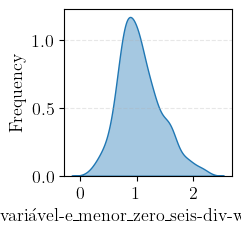

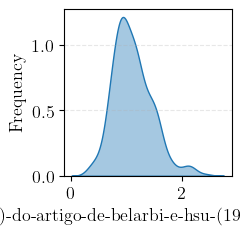

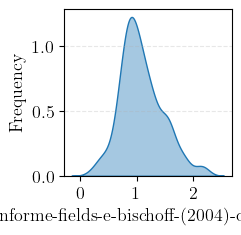

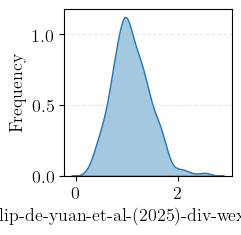

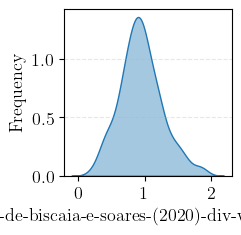

In [179]:
cols_compare = df_models.columns.tolist()
for i in cols_compare:
    ratio_data = df_models[i]
    width_cm = 5.5
    height_cm = 5.5
    inches_per_cm = 1 / 2.54
    width_in = width_cm * inches_per_cm
    height_in = height_cm * inches_per_cm
    y_axis_label = i
    label_size = 13
    axis_size = 13
    label_color = 'black'
    # KDE Plot
    plt.figure(figsize=(width_in, height_in))
    sns.kdeplot(data=ratio_data, fill=True, alpha=0.4)
    plt.tick_params(axis='both', which='major', labelsize=axis_size)
    plt.xlabel(y_axis_label, fontsize=label_size, color=label_color)
    plt.ylabel('Frequency', fontsize=label_size, color=label_color)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.savefig(f'z_fig_{i}.png', dpi=600, bbox_inches='tight')
    plt.show()

### Colocando em ordem de erro decrescente

In [ ]:
df['Divisoes'] = pd.qcut(df['abs_error'], q=10, labels=False)
df = df.sort_values(by='abs_error', ascending=False)

### Salvando os dados

In [ ]:
df.to_excel(f'estatistica_{modelo}.xlsx')
tabela = (f'estatistica_{modelo}.xlsx')
with pd.ExcelWriter(tabela, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    df[df['Divisoes'] == 9].describe().to_excel(writer, sheet_name='35 maiores erros (9 div)')
    df[df['Divisoes'] == 8].describe().to_excel(writer, sheet_name='34 erros (8 div)')
    df[df['Divisoes'] == 7].describe().to_excel(writer, sheet_name='34 erros (7 div)')
    df[df['Divisoes'] == 6].describe().to_excel(writer, sheet_name='34 erros (6 div)')
    df[df['Divisoes'] == 5].describe().to_excel(writer, sheet_name='34 erros (5 div)')
    df[df['Divisoes'] == 4].describe().to_excel(writer, sheet_name='34 erros (4 div)')
    df[df['Divisoes'] == 3].describe().to_excel(writer, sheet_name='34 erros (3 div)')
    df[df['Divisoes'] == 2].describe().to_excel(writer, sheet_name='34 erros (2 div)')
    df[df['Divisoes'] == 1].describe().to_excel(writer, sheet_name='33 erros (1 div)')
    df[df['Divisoes'] == 0].describe().to_excel(writer, sheet_name='36 erros (0 div)')

# Alguns gráficos

### KDE

0.24939348085232294
0.009889437262667314


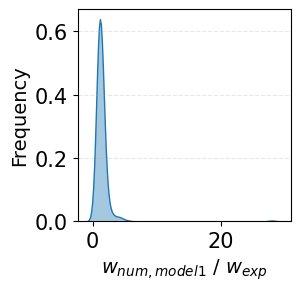

In [ ]:
tips = df[f'wexp_(mm)/{modelo}'] 

# Tamanho da Figura em Centímetros
width_cm = 7
height_cm = 7
inches_per_cm = 1 / 2.54
width_in = width_cm * inches_per_cm
height_in = height_cm * inches_per_cm

label_y_data = '$w_{num,model1}$ / $w_{exp}$'
tamanho_label = 14
cor_label = 'black'

# KDE
plt.figure(figsize=(width_in, height_in))

sns.kdeplot(data=tips, fill=True, alpha=0.4)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.xlabel(label_y_data, fontsize=tamanho_label, color=cor_label)
plt.ylabel('Frequency', fontsize=tamanho_label, color=cor_label)
plt.grid(axis='y', linestyle='--', alpha=0.3)
y_obse = df['wexp_(mm)']
y_pred = df[f'{modelo}']
print(r2_score(y_obse, y_pred))
print(mean_squared_error(y_obse, y_pred))
# plt.savefig('histograma_padrao.png', dpi=300)

### Scatterplot

In [ ]:
X_value = df['wexp_(mm)']
Y_value = df[modelo]

# Tamanho da Figura em Centímetros
width_cm = 18
height_cm = 12
inches_per_cm = 1 / 2.54
width_in = width_cm * inches_per_cm
height_in = height_cm * inches_per_cm

# Título e Rótulos
label_x = '$w_{exp}$ (mm)'
label_y = 'Modelo'
tamanho_label = 14
cor_label = 'black'

# Configurações do Scatter Plot
tamanho_pontos = 30
cor_cmap = 'viridis'
alpha_transparencia = 0.7
cor_borda_ponto = 'black'
espessura_borda_ponto = 0.8

#Configurações da linha de regressão
cor_linha_regressao = 'red'
estilo_linha_regressao = '--'
espessura_linha_regressao = 1

#SCATTER PLOT SEM BARRA DE CORES
plt.figure(figsize=(width_in, height_in))
plt.scatter(X_value, Y_value,
                s=tamanho_pontos,
                c='blue',
                alpha=alpha_transparencia,
                edgecolors=cor_borda_ponto,
                linewidths=espessura_borda_ponto)

x_line = np.array([0, X_value.max()])
y_line = x_line
plt.plot(x_line, y_line,
        color=cor_linha_regressao,
        linestyle=estilo_linha_regressao,
        linewidth=espessura_linha_regressao,
        label='Linha de Regressão',
        zorder=1)

plt.tick_params(axis='both', which='major', labelsize=20)
plt.xlabel(label_x, fontsize=tamanho_label, color=cor_label)
plt.ylabel(label_y, fontsize=tamanho_label, color=cor_label)
plt.grid(True, linestyle='--', alpha=0.3)



y1 = df['wexp (mm)']
x1 = df[modelo]
print(r2_score(y1, x1))
print(mean_squared_error(y1, x1))

plt.show()
#plt.savefig('scatter_plot_sem_legenda_linha_diagonal.png', dpi=300)

KeyError: 'wexp (mm)'